# Pairs Trading & Statistical Arbitrage
## 06 - Transaction Costs

This notebook incorporates realistic transaction costs into the V/MA pairs trading backtest. A strategy that looks profitable before costs but breaks down after is not a viable strategy - transaction costs are a required component of any honest backtest.

### Cost Assumptions
We model transaction costs as a fixed percentage applied per side per trade. Both legs of the pairs trade are affected on both entry and exit, so the total round trip cost is four times the per-side assumption.

- Realistic: 0.05% per side - appropriate for liquid large cap equities like V and MA with modern zero-commission brokers where the primary cost is the bid-ask spread
- Conservative: 0.10% per side
- High: 0.25% per side - representative of less liquid assets or higher friction environments

### Results

| Cost Assumption | Ann. Return | Sharpe | Max Drawdown |
|---|---|---|---|
| No costs | 3.40% | 0.44 | -12.67% |
| Realistic (0.05%) | 2.64% | 0.34 | -13.44% |
| Conservative (0.10%) | 1.88% | 0.24 | -14.73% |
| High (0.25%) | -0.40% | -0.05 | -21.85% |

### Why Transaction Costs Matter Even for Low Frequency Strategies
The strategy executed only 31 trades over 15 years - roughly 2 trades per year with an average hold period of 64.6 days. At this frequency, transaction costs should be nearly negligible. However, the results show a meaningful drag even at realistic cost levels.

The reason is a subset of trades where the signal is weak - the z-score barely crosses the entry threshold, generates a short trade, and exits quickly without meaningful spread reversion. These whipsaw trades pay full round trip costs while generating little or no return. Trade 6 in the sample is a clear example - a 10 day trade that immediately reversed direction, incurring two round trip costs within two weeks.

### Conclusion
At realistic transaction cost assumptions of 5 basis points per side the strategy remains viable with a positive Sharpe ratio and manageable drawdown. At 25 basis points the strategy is no longer profitable. For a retail trader using a modern zero-commission broker trading liquid large cap equities, the 5 basis point assumption is defensible and the strategy survives cost scrutiny.

### Limitation
Transaction costs are modeled as fixed and symmetric. In practice costs vary by trade size, time of day, and market conditions. Larger positions would face greater market impact, and costs during periods of high volatility - exactly when spreads widen most - would likely be higher than the base assumption.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Reload prices
tickers = ["V", "MA"]
raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices = raw.dropna()

log_returns = np.log(prices / prices.shift(1))

print(f"Loaded: {prices.shape[0]} days")
print(prices.tail())

[*********************100%***********************]  2 of 2 completed

Loaded: 4178 days
Ticker              MA           V
Date                              
2026-08-07  562.950012  361.827820
2026-08-10  563.169983  360.650024
2026-08-11  561.440002  362.820007
2026-08-12  559.729980  359.420013
2026-08-13  567.039978  365.450012


In [3]:
def run_strategy(prices, window=252, entry_threshold=2.0, cost_per_trade=0.001):
    """
    Runs the V/MA pairs trading strategy with transaction costs.
    
    Parameters:
    - window: rolling window for hedge ratio and z-score
    - entry_threshold: z-score level to enter a trade
    - cost_per_trade: one way transaction cost as a fraction (0.001 = 0.1%)
      Applied to both legs on entry and exit, so round trip = 4x cost_per_trade
    
    Returns:
    - strategy_returns: daily returns after costs
    - signals: position signals
    - zscore: z-score series
    - trades: DataFrame of all trades with entry/exit dates and PnL
    """
    log_returns = np.log(prices / prices.shift(1))
    
    # Rolling hedge ratio
    rolling_beta = pd.Series(index=prices.index, dtype=float)
    rolling_alpha = pd.Series(index=prices.index, dtype=float)
    
    for i in range(window, len(prices)):
        window_prices = prices.iloc[i-window:i]
        X = add_constant(window_prices["V"])
        y = window_prices["MA"]
        model = OLS(y, X).fit()
        rolling_beta.iloc[i] = model.params["V"]
        rolling_alpha.iloc[i] = model.params["const"]
    
    # Spread and z-score
    spread = prices["MA"] - (rolling_alpha + rolling_beta * prices["V"])
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    zscore = (spread - rolling_mean) / rolling_std
    
    # Signal generation with trade tracking
    signals = pd.Series(0.0, index=zscore.index)
    position = 0
    trade_log = []
    entry_date = None
    entry_return = 0
    
    for i in range(len(zscore)):
        z = zscore.iloc[i]
        date = zscore.index[i]
        
        if np.isnan(z):
            signals.iloc[i] = 0
            continue
        
        if position == 0:
            if z < -entry_threshold:
                position = 1
                entry_date = date
                entry_zscore = z
            elif z > entry_threshold:
                position = -1
                entry_date = date
                entry_zscore = z
        
        elif position == 1:
            if z >= 0:
                trade_log.append({
                    "entry_date": entry_date,
                    "exit_date": date,
                    "direction": "long spread",
                    "entry_zscore": entry_zscore,
                    "exit_zscore": z
                })
                position = 0
        
        elif position == -1:
            if z <= 0:
                trade_log.append({
                    "entry_date": entry_date,
                    "exit_date": date,
                    "direction": "short spread",
                    "entry_zscore": entry_zscore,
                    "exit_zscore": z
                })
                position = 0
        
        signals.iloc[i] = position
    
    # Base returns
    base_returns = (
        signals.shift(1) * log_returns["MA"] -
        signals.shift(1) * log_returns["V"]
    )
    
    # Transaction costs - applied on position changes
    # Round trip cost = 4 * cost_per_trade (entry and exit, both legs)
    position_changes = signals.diff().abs()
    cost_series = position_changes * cost_per_trade * 4
    
    strategy_returns = (base_returns - cost_series).dropna()
    
    trades = pd.DataFrame(trade_log)
    
    return strategy_returns, signals, zscore, trades

print("Strategy function ready")

Strategy function ready


In [4]:
def performance_summary(returns, label):
    ann_return = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    cumulative = returns.cumsum()
    drawdown = cumulative - cumulative.cummax()
    max_dd = drawdown.min()
    print(f"\n{label}")
    print(f"  Ann. Return: {ann_return:.2%}  Vol: {ann_vol:.2%}  Sharpe: {sharpe:.2f}  Max DD: {max_dd:.2%}")
    return ann_return, ann_vol, sharpe, max_dd

print("=" * 55)
print("TRANSACTION COST IMPACT")
print("=" * 55)

# No costs
r0, _, s0, d0 = performance_summary(
    run_strategy(prices, cost_per_trade=0.0)[0], 
    "No transaction costs"
)

# Realistic - 0.05% per side (liquid large cap)
r1, _, s1, d1 = performance_summary(
    run_strategy(prices, cost_per_trade=0.0005)[0],
    "Realistic costs (0.05% per side)"
)

# Conservative - 0.10% per side
r2, _, s2, d2 = performance_summary(
    run_strategy(prices, cost_per_trade=0.001)[0],
    "Conservative costs (0.10% per side)"
)

# Very conservative - 0.25% per side
r3, _, s3, d3 = performance_summary(
    run_strategy(prices, cost_per_trade=0.0025)[0],
    "High costs (0.25% per side)"
)

TRANSACTION COST IMPACT

No transaction costs
  Ann. Return: 3.40%  Vol: 7.78%  Sharpe: 0.44  Max DD: -12.67%

Realistic costs (0.05% per side)
  Ann. Return: 2.64%  Vol: 7.73%  Sharpe: 0.34  Max DD: -13.44%

Conservative costs (0.10% per side)
  Ann. Return: 1.88%  Vol: 7.69%  Sharpe: 0.24  Max DD: -14.73%

High costs (0.25% per side)
  Ann. Return: -0.40%  Vol: 7.69%  Sharpe: -0.05  Max DD: -21.85%


In [6]:
_, signals, zscore, trades = run_strategy(prices, cost_per_trade=0.0005)

# Calculate trade durations
trades["duration_days"] = (trades["exit_date"] - trades["entry_date"]).dt.days

print(f"Total trades: {len(trades)}")
print(f"Average trade duration: {trades['duration_days'].mean():.1f} days")
print(f"Long spread trades: {(trades['direction'] == 'long spread').sum()}")
print(f"Short spread trades: {(trades['direction'] == 'short spread').sum()}")
print(f"\nSample trades:")
print(trades.head(10))

Total trades: 31
Average trade duration: 64.6 days
Long spread trades: 13
Short spread trades: 18

Sample trades:
  entry_date  exit_date     direction  entry_zscore  exit_zscore  \
0 2011-12-30 2012-04-09   long spread     -2.330082     0.212623   
1 2013-07-31 2013-12-19  short spread      5.141687    -0.028591   
2 2014-01-17 2014-04-25   long spread     -3.003812     0.058865   
3 2015-02-20 2015-07-24  short spread      2.035602    -1.328433   
4 2015-11-13 2016-04-01   long spread     -2.073536     0.150136   
5 2016-10-25 2017-02-03  short spread      2.021765    -0.563160   
6 2018-01-23 2018-02-02   long spread     -2.035630     2.151125   
7 2018-02-05 2018-04-16  short spread      2.754175    -0.117367   
8 2018-07-19 2018-12-17   long spread     -2.048608     0.125293   
9 2019-01-31 2019-03-15  short spread      3.001885    -0.073416   

   duration_days  
0            101  
1            141  
2             98  
3            154  
4            140  
5            101  
6   

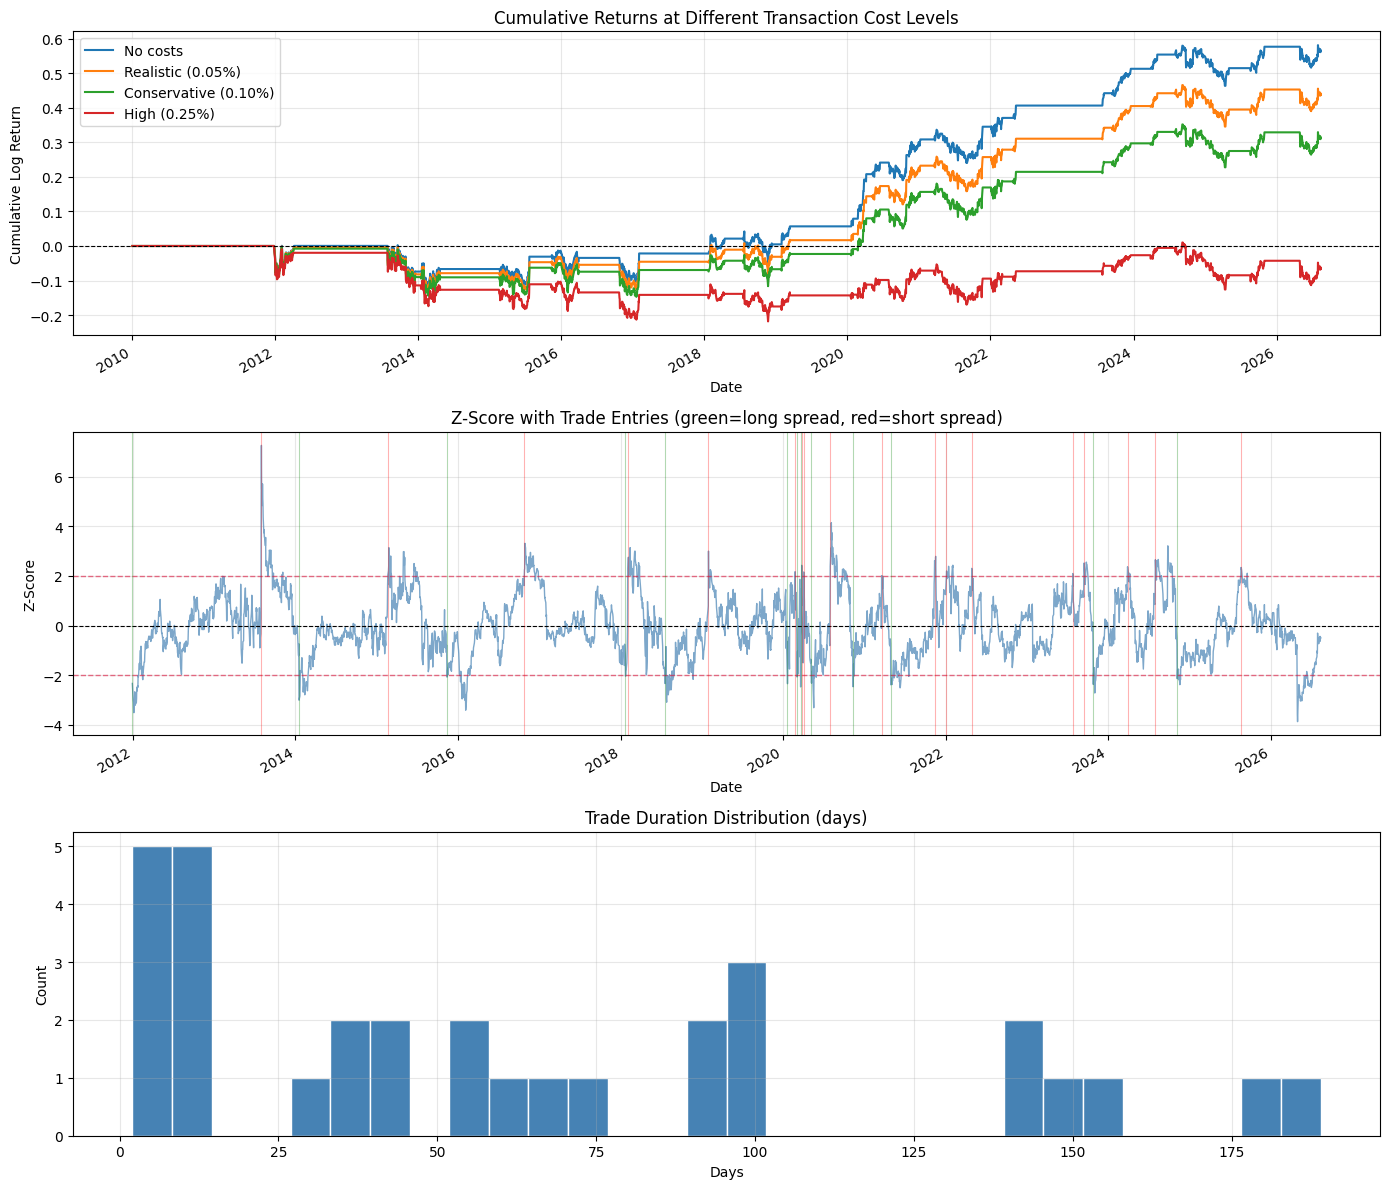

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

# Cumulative returns at different cost levels
ax1 = axes[0]
for cost, label, color in [
    (0.0, "No costs", "steelblue"),
    (0.0005, "Realistic (0.05%)", "seagreen"),
    (0.001, "Conservative (0.10%)", "darkorange"),
    (0.0025, "High (0.25%)", "crimson")
]:
    returns = run_strategy(prices, cost_per_trade=cost)[0]
    returns.cumsum().plot(ax=ax1, label=label, linewidth=1.5)

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Cumulative Returns at Different Transaction Cost Levels", fontsize=12)
ax1.set_ylabel("Cumulative Log Return")
ax1.legend()
ax1.grid(alpha=0.3)

# Z-score with entry/exit markers
ax2 = axes[1]
zscore.plot(ax=ax2, color="steelblue", linewidth=1, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axhline(2, color="crimson", linewidth=1, linestyle="--", alpha=0.6)
ax2.axhline(-2, color="crimson", linewidth=1, linestyle="--", alpha=0.6)

# Mark entry points
for _, trade in trades.iterrows():
    color = "green" if trade["direction"] == "long spread" else "red"
    ax2.axvline(trade["entry_date"], color=color, alpha=0.3, linewidth=0.8)

ax2.set_title("Z-Score with Trade Entries (green=long spread, red=short spread)", fontsize=12)
ax2.set_ylabel("Z-Score")
ax2.grid(alpha=0.3)

# Trade duration distribution
ax3 = axes[2]
trades["duration_days"].hist(ax=ax3, bins=30, color="steelblue", edgecolor="white")
ax3.set_title("Trade Duration Distribution (days)", fontsize=12)
ax3.set_xlabel("Days")
ax3.set_ylabel("Count")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()